
===== CROSS-SESSION REACH-MODULATED HEATMAPS =====
  Session 1: 50 units shown / 78 reach-modulated / 98 total
  Session 2: 50 units shown / 177 reach-modulated / 189 total

Color scale: ±7.0


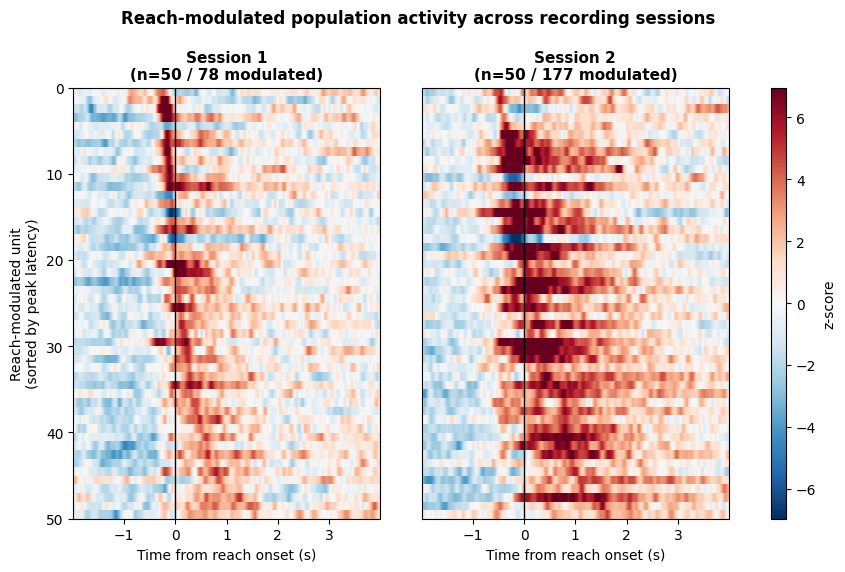


Saved → GRANT_per_session_heatmaps.png/.pdf/.svg

===== DONE =====



In [2]:
# ============================================================
# CROSS-SESSION REACH-MODULATED HEATMAPS (independent pools)
# ============================================================
# For each chosen session: sample N reach-modulated units (random),
# sort by peak latency within that session, plot heatmap.
# Different units per session. No cross-session matching.
# Purpose: "reach-modulated activity is present and structured on every
# recording day" — generic prelim credibility figure.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

print("\n===== CROSS-SESSION REACH-MODULATED HEATMAPS =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_FOLDER = r"G:\Kevin\unit_matching"

N_UNITS_PER_SESSION = 50    # target sample size; caps at available count
RANDOM_SEED = 42
REACH_ARRAYS_NAME = "reach_good_in_trial_arrays.npz"   # Cell M-v3 output
# ------------------------------------------------------------

output_folder = Path(OUTPUT_FOLDER)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# LOAD PER-SESSION Z-PSTHs FOR REACH-MODULATED UNITS
# ------------------------------------------------------------
session_data = []
for sf, lab in zip(SESSION_ANALYSIS_FOLDERS, SESSION_LABELS):
    af = Path(sf)
    ra_path = af / "qc" / REACH_ARRAYS_NAME
    if not ra_path.exists():
        raise FileNotFoundError(f"{ra_path} not found — run Cell M-v3 first.")
    ra = np.load(ra_path)
    units      = ra["units"]
    z_psth     = ra["z_mean"]
    modulated  = ra["modulated"]
    peak_lat   = None
    if "peak_latency" in ra.files:
        peak_lat = ra["peak_latency"]
    centers    = ra["centers"]

    mod_idx = np.where(modulated)[0]
    n_available = len(mod_idx)
    n_take = min(N_UNITS_PER_SESSION, n_available)
    if n_take < N_UNITS_PER_SESSION:
        print(f"  {lab}: only {n_available} reach-modulated units "
              f"(requested {N_UNITS_PER_SESSION}). Showing all.")
    chosen = rng.choice(mod_idx, size=n_take, replace=False)

    # If peak_latency wasn't stored, compute it on the fly from z_psth within response window
    if peak_lat is None:
        rwin = (-0.5, 2.0)
        resp_mask = (centers >= rwin[0]) & (centers < rwin[1])
        abs_z = np.abs(z_psth[chosen][:, resp_mask])
        peak_idx_in_resp = np.argmax(abs_z, axis=1)
        resp_centers = centers[resp_mask]
        chosen_peak_lat = resp_centers[peak_idx_in_resp]
    else:
        chosen_peak_lat = peak_lat[chosen]

    session_data.append({
        "label": lab,
        "z": z_psth[chosen],
        "peak_lat": chosen_peak_lat,
        "centers": centers,
        "n_units": n_take,
        "n_available": n_available,
        "total_units": len(units),
    })
    print(f"  {lab}: {n_take} units shown / {n_available} reach-modulated "
          f"/ {len(units)} total")

# Shared color scale (98th percentile of |z| across all chosen units, floored)
all_z = np.concatenate([d["z"].ravel() for d in session_data])
vmax = max(np.percentile(np.abs(all_z), 98), 3.0)
print(f"\nColor scale: ±{vmax:.1f}")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(4.2 * n_sessions + 0.8, 5.6))
gs = GridSpec(1, n_sessions + 1,
              width_ratios=[1] * n_sessions + [0.05], wspace=0.20)

for si, d in enumerate(session_data):
    ax = fig.add_subplot(gs[0, si])
    order = np.argsort(d["peak_lat"])
    sorted_z = d["z"][order]
    im = ax.imshow(sorted_z, aspect="auto",
                   extent=[d["centers"][0], d["centers"][-1],
                           d["n_units"], 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.0)
    ax.set_xlabel("Time from reach onset (s)")
    if si == 0:
        ax.set_ylabel("Reach-modulated unit\n(sorted by peak latency)")
    else:
        ax.set_yticks([])
    ax.set_title(f"{d['label']}\n(n={d['n_units']} / {d['n_available']} modulated)",
                 fontsize=11, fontweight="bold")

cax = fig.add_subplot(gs[0, -1])
plt.colorbar(im, cax=cax, label="z-score")

plt.suptitle("Reach-modulated population activity across recording sessions",
             fontsize=12, fontweight="bold", y=1.02)

out_base = output_folder / "GRANT_per_session_heatmaps"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.svg", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {out_base.name}.png/.pdf/.svg")

print("\n===== DONE =====\n")


===== CROSS-SESSION PAIRWISE CORRELATIONS =====
Tracked units present in all 3 sessions: 22

Loading spike times for tracked units...
  S1 reach: 80 events × 22 units
  S1 tone: 71 events × 22 units
  S1 random: 100 events × 22 units
  S2 reach: 112 events × 22 units
  S2 tone: 87 events × 22 units
  S2 random: 100 events × 22 units
  S3 reach: 119 events × 22 units
  S3 tone: 48 events × 22 units
  S3 random: 100 events × 22 units


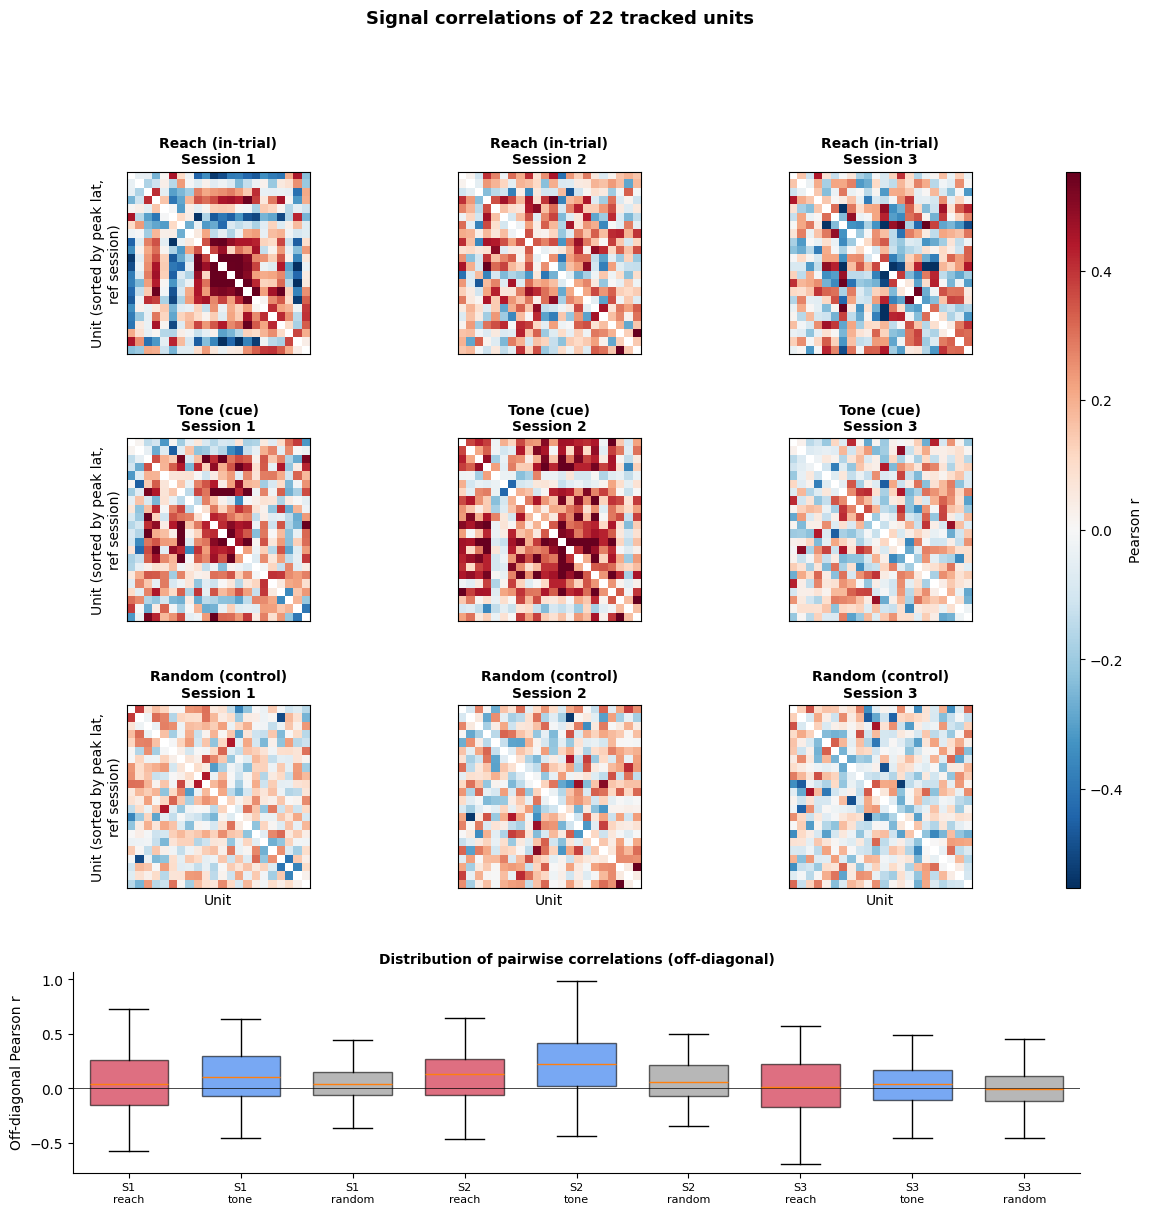

Saved → GRANT_signal_correlations.png/.pdf/.svg


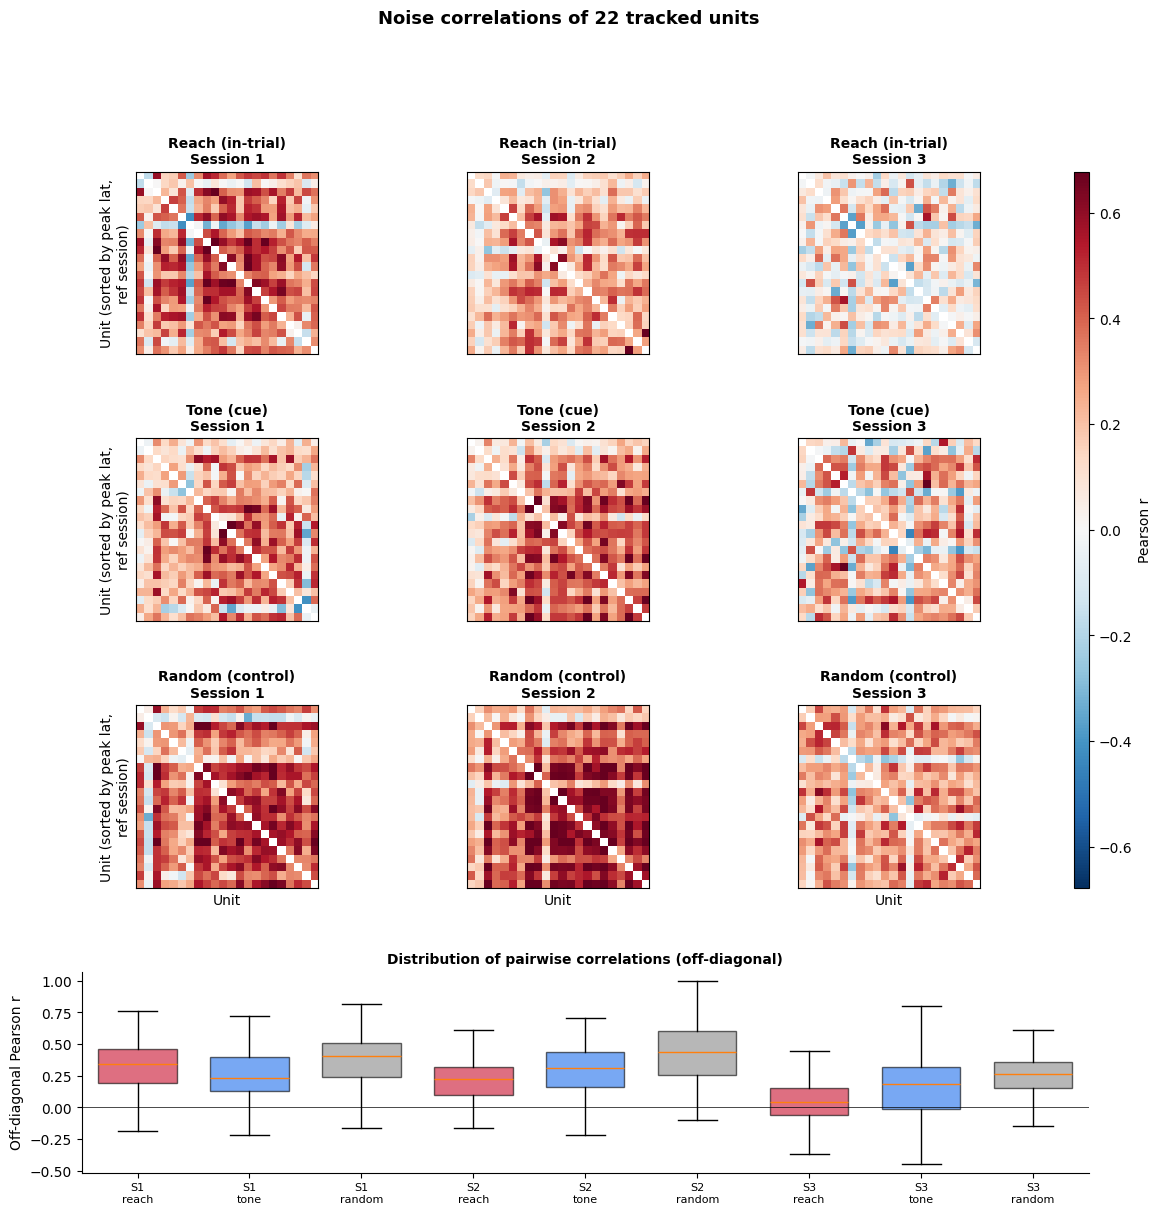

Saved → GRANT_noise_correlations.png/.pdf/.svg

===== Median |off-diagonal correlation| per condition =====
Event        Session 1   Session 2   Session 3

[SIGNAL]
reach            0.230       0.180       0.204
tone             0.200       0.234       0.127
random           0.121       0.144       0.115

[NOISE]
reach            0.344       0.223       0.114
tone             0.242       0.309       0.231
random           0.402       0.438       0.262

===== DONE =====



In [2]:
# ============================================================
# CROSS-SESSION PAIRWISE CORRELATIONS — TRACKED UNITS
# ============================================================
# For tracked units across chosen sessions, computes:
#   - Signal correlations (trial-mean spike counts) per event type
#   - Noise correlations (trial residuals after subtracting unit mean)
# Event types: reach, tone, random control
# Output: two figures (signal, noise), each with event x session matrices
# plus a summary panel comparing off-diagonal correlation distributions.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

print("\n===== CROSS-SESSION PAIRWISE CORRELATIONS =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_BASE = r"G:\Kevin\unit_matching"

WINDOW_S = (0.0, 2.0)        # spike-count window post-event
REFERENCE_SESSION_IDX = 0    # for sorting unit row/column order
RANDOM_SEED = 42
N_RANDOM_EVENTS = 100        # # of random control events to draw per session
TONE_PIN = 4                 # pin for tone TTLs
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
focus_names = [Path(sf).name for sf in SESSION_ANALYSIS_FOLDERS]
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# LOAD CHAINS, FILTER TO TRACKED UNITS
# ------------------------------------------------------------
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
all_session_names = list(ch["session_names"])
units_by_session_full = ch["units_by_session"]

focus_cols = []
for fn in focus_names:
    if fn not in all_session_names:
        raise RuntimeError(f"{fn} not in chains. Re-run Cell Z.")
    focus_cols.append(all_session_names.index(fn))

units_focus_all = units_by_session_full[:, focus_cols]
keep_mask = (units_focus_all >= 0).all(axis=1)
units_focus = units_focus_all[keep_mask]   # (n_units, n_sessions)
n_units = len(units_focus)
print(f"Tracked units present in all {n_sessions} sessions: {n_units}")

# ------------------------------------------------------------
# LOAD EVENTS PER SESSION (+ session duration)
# ------------------------------------------------------------
import json
session_events = []   # list of dicts: {"reach": [...], "tone": [...], "random": [...]}
session_durations = []
for sf in SESSION_ANALYSIS_FOLDERS:
    af = Path(sf)
    with open(af / "metadata" / "session.json") as f:
        sess = json.load(f)
    dur = float(sess["recording_duration_s"])
    session_durations.append(dur)

    bouts = np.load(af / "peak_detection" / "bouts.npz")
    reach = np.sort(bouts["onset_t"][bouts["trial_id"] >= 0])
    tone = np.sort(np.load(af / "ttls" / f"TTL_Pin_{TONE_PIN}.npy"))

    # random control: uniform within the recording, away from edges
    win_pre = abs(WINDOW_S[0])
    win_post = WINDOW_S[1]
    t_min = win_pre + 1.0; t_max = dur - win_post - 1.0
    random_events = np.sort(rng.uniform(t_min, t_max, size=N_RANDOM_EVENTS))

    session_events.append({"reach": reach, "tone": tone, "random": random_events})

# ------------------------------------------------------------
# COMPUTE PER-TRIAL SPIKE COUNTS FOR EACH (session, unit, event)
# Build a matrix of shape (n_events, n_units) per (session, event_type)
# ------------------------------------------------------------
def spike_counts_per_trial(spike_times, events, win):
    """Return array of length len(events): spike count in (event+win[0], event+win[1])."""
    if len(spike_times) == 0 or len(events) == 0:
        return np.zeros(len(events))
    counts = np.zeros(len(events))
    for i, t in enumerate(events):
        lo = t + win[0]; hi = t + win[1]
        counts[i] = np.searchsorted(spike_times, hi) - np.searchsorted(spike_times, lo)
    return counts

# Pre-load spike times for all tracked units in all sessions
print("\nLoading spike times for tracked units...")
spikes_per_session = []   # list of dicts: {unit_id: spike_array} per session
for si, sf in enumerate(SESSION_ANALYSIS_FOLDERS):
    spikes_dir = Path(sf) / "spikes"
    sd = {}
    for ui in range(n_units):
        uid = int(units_focus[ui, si])
        sd[uid] = np.sort(np.load(spikes_dir / f"unit_{uid}.npy"))
    spikes_per_session.append(sd)

# Build trial-by-unit count matrices
event_types = ["reach", "tone", "random"]
event_labels = {"reach": "Reach (in-trial)",
                "tone": "Tone (cue)",
                "random": "Random (control)"}
counts = {evt: [] for evt in event_types}   # counts[evt][si] = (n_events, n_units)
for si in range(n_sessions):
    for evt in event_types:
        events = session_events[si][evt]
        mat = np.zeros((len(events), n_units))
        for ui in range(n_units):
            uid = int(units_focus[ui, si])
            mat[:, ui] = spike_counts_per_trial(spikes_per_session[si][uid],
                                                events, WINDOW_S)
        counts[evt].append(mat)
        print(f"  S{si+1} {evt}: {mat.shape[0]} events × {mat.shape[1]} units")

# ------------------------------------------------------------
# SIGNAL AND NOISE CORRELATION MATRICES
# ------------------------------------------------------------
# Signal: correlation across units of the TRIAL-AVERAGED counts
#   --> for n_events ≥ 2, just take mean across trials per unit per session,
#   --> but we have multiple sessions; per-(session,event) signal corr is
#   between units USING trial-averaged response — degenerate (one number
#   per unit). The standard signal-corr definition uses correlation
#   across DIFFERENT STIMULI of the trial-averaged responses. With one
#   event type, there's no "stimulus" axis.
#
# Cleaner definitions for this 1-event-type case:
#   - PSTH-based signal: corr between PSTHs (time-binned firing rates,
#     averaged over trials). Captures shared time course.
#   - Trial-by-trial signal: corr of trial-by-trial counts between units.
#     Captures co-fluctuation. THIS is closer to "noise correlation" but
#     since stimulus is the same on every trial, also includes signal.
#
# Best practice with one event type:
#   - "Signal corr" = corr of PSTH shapes (time-resolved, averaged across trials).
#   - "Noise corr" = corr of per-trial counts AFTER subtracting the unit's
#     mean count over all trials of that event.
# ------------------------------------------------------------

# Need time-resolved PSTHs for signal correlations
BIN_SIZE_PSTH = 0.050
edges = np.arange(WINDOW_S[0], WINDOW_S[1] + BIN_SIZE_PSTH, BIN_SIZE_PSTH)

def psth_for_unit(spike_times, events, win, bin_size):
    """Returns mean rate per bin (averaged across events)."""
    edges = np.arange(win[0], win[1] + bin_size, bin_size)
    per_event = np.zeros((len(events), len(edges) - 1))
    for i, t in enumerate(events):
        rel = spike_times[(spike_times >= t + win[0]) &
                          (spike_times <  t + win[1])] - t
        h, _ = np.histogram(rel, bins=edges)
        per_event[i] = h / bin_size
    return per_event.mean(axis=0)

# Per (session, event), per unit: PSTH for signal corr
psths = {evt: [] for evt in event_types}
for si in range(n_sessions):
    for evt in event_types:
        events = session_events[si][evt]
        mat = np.zeros((n_units, len(edges) - 1))
        for ui in range(n_units):
            uid = int(units_focus[ui, si])
            mat[ui] = psth_for_unit(spikes_per_session[si][uid], events,
                                    WINDOW_S, BIN_SIZE_PSTH)
        psths[evt].append(mat)

# Signal correlation matrix: corrcoef of PSTHs across units
signal_corr = {evt: [] for evt in event_types}
for si in range(n_sessions):
    for evt in event_types:
        psth = psths[evt][si]   # (n_units, n_bins)
        # Drop units with zero variance to avoid NaN
        stds = psth.std(axis=1)
        valid = stds > 0
        cm = np.full((n_units, n_units), np.nan)
        if valid.sum() >= 2:
            cm_valid = np.corrcoef(psth[valid])
            idx_valid = np.where(valid)[0]
            for i_v, ii in enumerate(idx_valid):
                for j_v, jj in enumerate(idx_valid):
                    cm[ii, jj] = cm_valid[i_v, j_v]
        signal_corr[evt].append(cm)

# Noise correlation matrix: corrcoef across trials of mean-subtracted counts
noise_corr = {evt: [] for evt in event_types}
for si in range(n_sessions):
    for evt in event_types:
        c = counts[evt][si]   # (n_events, n_units)
        if c.shape[0] < 2:
            noise_corr[evt].append(np.full((n_units, n_units), np.nan))
            continue
        resid = c - c.mean(axis=0, keepdims=True)
        stds = resid.std(axis=0)
        valid = stds > 0
        cm = np.full((n_units, n_units), np.nan)
        if valid.sum() >= 2:
            cm_valid = np.corrcoef(resid[:, valid], rowvar=False)
            idx_valid = np.where(valid)[0]
            for i_v, ii in enumerate(idx_valid):
                for j_v, jj in enumerate(idx_valid):
                    cm[ii, jj] = cm_valid[i_v, j_v]
        noise_corr[evt].append(cm)

# ------------------------------------------------------------
# UNIT ORDER FOR MATRICES (sort by peak latency on reference session)
# ------------------------------------------------------------
fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fps.append(fp)
def uidx_in_fp(fp, uid):
    return int(np.where(fp["unit_ids"] == uid)[0][0])
ref_latencies = np.array([
    float(fps[REFERENCE_SESSION_IDX]["reach_peak_lat"][
        uidx_in_fp(fps[REFERENCE_SESSION_IDX], int(units_focus[ui, REFERENCE_SESSION_IDX]))
    ])
    for ui in range(n_units)
])
order = np.argsort(ref_latencies)

# ------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------
def plot_matrices(corr_dict, title, fname):
    n_evt = len(event_types)
    fig = plt.figure(figsize=(4.0 * n_sessions + 1.0, 3.5 * n_evt + 2.5))
    gs = GridSpec(n_evt + 1, n_sessions + 1,
                  height_ratios=[1] * n_evt + [1.1],
                  width_ratios=[1] * n_sessions + [0.05],
                  hspace=0.45, wspace=0.18)

    # Shared color scale across all panels (98th percentile of |off-diagonal|)
    all_off = []
    for evt in event_types:
        for si in range(n_sessions):
            m = corr_dict[evt][si]
            mask = ~np.eye(n_units, dtype=bool)
            v = m[mask]
            all_off.append(v[np.isfinite(v)])
    all_off = np.concatenate(all_off)
    vmax = max(np.percentile(np.abs(all_off), 98), 0.3)

    for ei, evt in enumerate(event_types):
        for si in range(n_sessions):
            ax = fig.add_subplot(gs[ei, si])
            cm = corr_dict[evt][si][np.ix_(order, order)]
            # Mask the diagonal for clearer visualization
            cm_display = cm.copy()
            np.fill_diagonal(cm_display, np.nan)
            im = ax.imshow(cm_display, cmap="RdBu_r",
                           vmin=-vmax, vmax=vmax,
                           interpolation="nearest")
            ax.set_title(f"{event_labels[evt]}\n{SESSION_LABELS[si]}",
                         fontsize=10, fontweight="bold")
            if si == 0:
                ax.set_ylabel("Unit (sorted by peak lat,\nref session)")
            if ei == n_evt - 1:
                ax.set_xlabel("Unit")
            ax.set_xticks([]); ax.set_yticks([])

    # Single colorbar on the right
    cax = fig.add_subplot(gs[:n_evt, -1])
    plt.colorbar(im, cax=cax, label="Pearson r")

    # Summary panel: off-diagonal distributions
    ax_sum = fig.add_subplot(gs[n_evt, :])
    bins = np.linspace(-vmax * 1.2, vmax * 1.2, 50)
    evt_colors = {"reach": "#C8102E", "tone": "#1f6feb", "random": "#888888"}
    positions = np.arange(n_sessions * len(event_types))
    box_data = []; labels_x = []; color_seq = []
    for si in range(n_sessions):
        for evt in event_types:
            m = corr_dict[evt][si]
            mask = ~np.eye(n_units, dtype=bool)
            v = m[mask]
            v = v[np.isfinite(v)]
            box_data.append(v)
            labels_x.append(f"{SESSION_LABELS[si].replace('Session ', 'S')}\n{evt}")
            color_seq.append(evt_colors[evt])
    bp = ax_sum.boxplot(box_data, positions=positions, widths=0.7,
                        patch_artist=True, showfliers=False)
    for patch, col in zip(bp["boxes"], color_seq):
        patch.set_facecolor(col); patch.set_alpha(0.6)
    ax_sum.axhline(0, color="black", lw=0.5)
    ax_sum.set_xticks(positions)
    ax_sum.set_xticklabels(labels_x, fontsize=8)
    ax_sum.set_ylabel("Off-diagonal Pearson r")
    ax_sum.set_title("Distribution of pairwise correlations (off-diagonal)",
                     fontsize=10, fontweight="bold")
    ax_sum.spines[["top", "right"]].set_visible(False)

    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.005)
    for ext in ("png", "pdf", "svg"):
        plt.savefig(output_base / f"{fname}.{ext}",
                    dpi=300 if ext == "png" else None,
                    bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved → {fname}.png/.pdf/.svg")

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
plot_matrices(signal_corr,
              f"Signal correlations of {n_units} tracked units",
              "GRANT_signal_correlations")
plot_matrices(noise_corr,
              f"Noise correlations of {n_units} tracked units",
              "GRANT_noise_correlations")

# ------------------------------------------------------------
# QUANTITATIVE SUMMARY
# ------------------------------------------------------------
print("\n===== Median |off-diagonal correlation| per condition =====")
print(f"{'Event':<10}" + "".join(f"{lab:>12}" for lab in SESSION_LABELS))
for kind_name, corr_dict in [("SIGNAL", signal_corr), ("NOISE", noise_corr)]:
    print(f"\n[{kind_name}]")
    for evt in event_types:
        row = f"{evt:<10}"
        for si in range(n_sessions):
            m = corr_dict[evt][si]
            mask = ~np.eye(n_units, dtype=bool)
            v = m[mask]; v = v[np.isfinite(v)]
            row += f"{np.median(np.abs(v)):>12.3f}"
        print(row)

print("\n===== DONE =====\n")


===== CORRELATION vs LATENCY DIFFERENCE =====
Tracked units present in all 3 sessions: 22


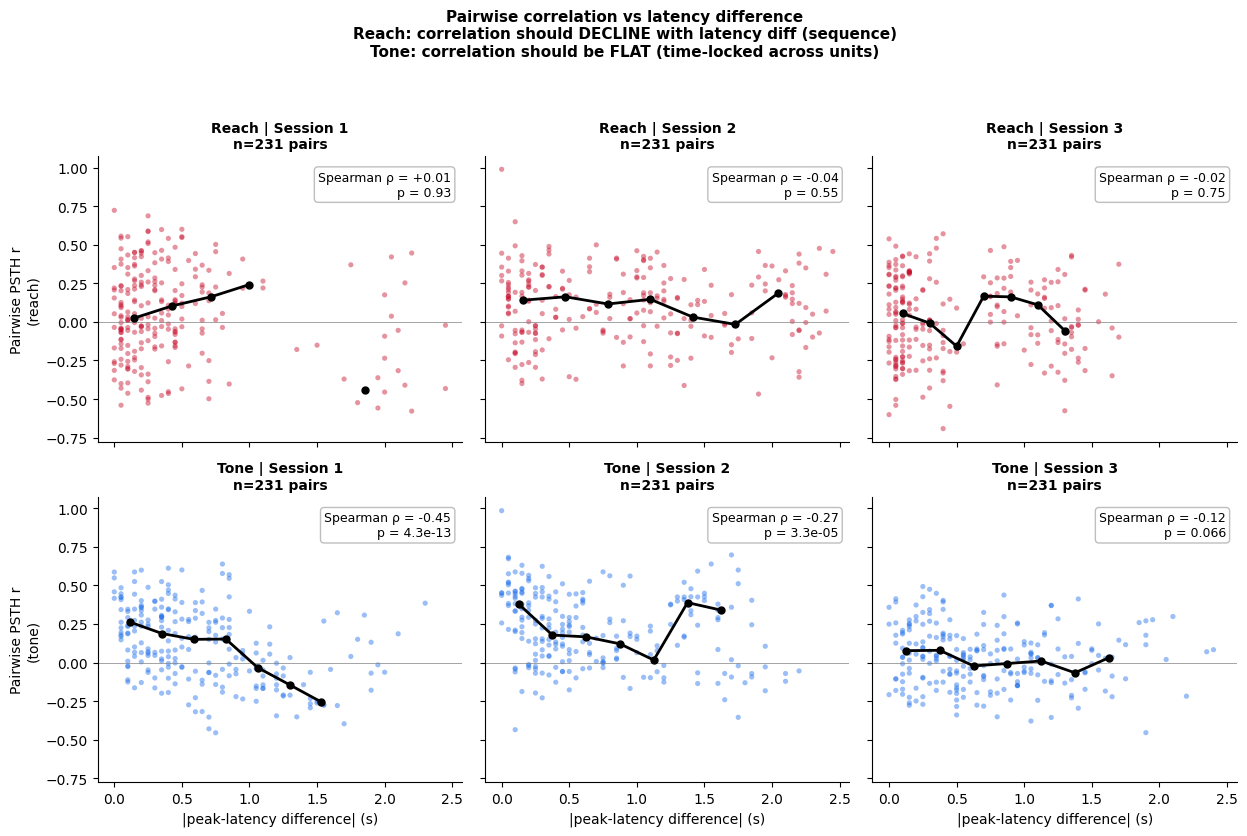

Saved → GRANT_correlation_vs_latency_diff.png/.pdf/.svg

===== Summary =====

REACH:
  Session 1: Spearman ρ = +0.006, p = 0.928 (n=231 pairs)
  Session 2: Spearman ρ = -0.039, p = 0.551 (n=231 pairs)
  Session 3: Spearman ρ = -0.021, p = 0.751 (n=231 pairs)

TONE:
  Session 1: Spearman ρ = -0.453, p = 4.32e-13 (n=231 pairs)
  Session 2: Spearman ρ = -0.270, p = 3.27e-05 (n=231 pairs)
  Session 3: Spearman ρ = -0.121, p = 0.066 (n=231 pairs)

===== DONE =====



In [3]:
# ============================================================
# CORRELATION vs LATENCY DIFFERENCE — TRACKED UNITS
# ============================================================
# For each pair of tracked units, plots their pairwise PSTH
# correlation (signal correlation) against the absolute difference
# in their peak latencies, for reach vs tone events.
#
# Hypothesis: reach activity tiles the movement phase sequentially
# (units with different latencies have anticorrelated PSTHs;
# units with similar latencies are correlated). Tone activity is
# time-locked across units (correlation is high regardless of
# latency difference).
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

print("\n===== CORRELATION vs LATENCY DIFFERENCE =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_BASE = r"G:\Kevin\unit_matching"

WINDOW_S = (0.0, 2.0)
BIN_SIZE = 0.050
TONE_PIN = 4
RESPONSE_WIN_FOR_PEAK = (-0.5, 2.0)   # window for finding peak latency
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
focus_names = [Path(sf).name for sf in SESSION_ANALYSIS_FOLDERS]

# ------------------------------------------------------------
# LOAD TRACKED UNITS
# ------------------------------------------------------------
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
all_session_names = list(ch["session_names"])
units_by_session_full = ch["units_by_session"]
focus_cols = [all_session_names.index(fn) for fn in focus_names]
units_focus_all = units_by_session_full[:, focus_cols]
keep_mask = (units_focus_all >= 0).all(axis=1)
units_focus = units_focus_all[keep_mask]
n_units = len(units_focus)
print(f"Tracked units present in all {n_sessions} sessions: {n_units}")

# ------------------------------------------------------------
# LOAD EVENTS AND SPIKES
# ------------------------------------------------------------
session_events = []
spikes_per_session = []
for sf in SESSION_ANALYSIS_FOLDERS:
    af = Path(sf)
    bouts = np.load(af / "peak_detection" / "bouts.npz")
    reach = np.sort(bouts["onset_t"][bouts["trial_id"] >= 0])
    tone = np.sort(np.load(af / "ttls" / f"TTL_Pin_{TONE_PIN}.npy"))
    session_events.append({"reach": reach, "tone": tone})

    spikes_dir = af / "spikes"
    sd = {int(uid): np.sort(np.load(spikes_dir / f"unit_{int(uid)}.npy"))
          for uid in units_focus[:, SESSION_ANALYSIS_FOLDERS.index(sf)]}
    spikes_per_session.append(sd)

# ------------------------------------------------------------
# COMPUTE PSTH AND PEAK LATENCY PER (SESSION, EVENT, UNIT)
# ------------------------------------------------------------
edges = np.arange(WINDOW_S[0], WINDOW_S[1] + BIN_SIZE, BIN_SIZE)
centers = edges[:-1] + BIN_SIZE / 2

# For peak-latency computation, use a wider window so we can find peaks
# that may fall before time 0 (pre-event activity)
edges_full = np.arange(RESPONSE_WIN_FOR_PEAK[0],
                       RESPONSE_WIN_FOR_PEAK[1] + BIN_SIZE, BIN_SIZE)
centers_full = edges_full[:-1] + BIN_SIZE / 2

def psth_for_unit(spike_times, events, win_edges):
    per_event = np.zeros((len(events), len(win_edges) - 1))
    for i, t in enumerate(events):
        rel = spike_times[(spike_times >= t + win_edges[0]) &
                          (spike_times <  t + win_edges[-1])] - t
        h, _ = np.histogram(rel, bins=win_edges)
        per_event[i] = h / BIN_SIZE
    return per_event.mean(axis=0)

event_types = ["reach", "tone"]
# psths[evt][session_idx] = (n_units, n_bins) using WINDOW_S
# peak_lat[evt][session_idx] = (n_units,) using RESPONSE_WIN_FOR_PEAK
psths = {evt: [] for evt in event_types}
peak_lat = {evt: [] for evt in event_types}

for si, fp_path in enumerate(SESSION_ANALYSIS_FOLDERS):
    sd = spikes_per_session[si]
    for evt in event_types:
        events = session_events[si][evt]
        psth_mat = np.zeros((n_units, len(centers)))
        peak_arr = np.zeros(n_units)
        for ui in range(n_units):
            uid = int(units_focus[ui, si])
            spk = sd[uid]
            # PSTH for correlation (post-event window)
            psth_mat[ui] = psth_for_unit(spk, events, edges)
            # Peak latency from a wider window
            full_psth = psth_for_unit(spk, events, edges_full)
            # baseline-subtract to find true peak relative to background
            full_psth_dev = full_psth - full_psth.mean()
            peak_arr[ui] = centers_full[np.argmax(np.abs(full_psth_dev))]
        psths[evt].append(psth_mat)
        peak_lat[evt].append(peak_arr)

# ------------------------------------------------------------
# PAIRWISE CORRELATIONS AND LATENCY DIFFERENCES
# ------------------------------------------------------------
pair_results = {evt: [] for evt in event_types}   # list per session of dicts
for si in range(n_sessions):
    for evt in event_types:
        psth_mat = psths[evt][si]
        lat_arr = peak_lat[evt][si]
        # valid units = nonzero variance
        valid = psth_mat.std(axis=1) > 0
        idx = np.where(valid)[0]
        n_v = len(idx)
        rs, dts = [], []
        for i in range(n_v):
            for j in range(i + 1, n_v):
                ii, jj = idx[i], idx[j]
                r = np.corrcoef(psth_mat[ii], psth_mat[jj])[0, 1]
                dt = abs(lat_arr[ii] - lat_arr[jj])
                rs.append(r); dts.append(dt)
        pair_results[evt].append({
            "r": np.array(rs),
            "dt": np.array(dts),
            "n_pairs": len(rs),
        })

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, axes = plt.subplots(2, n_sessions, figsize=(4.2 * n_sessions, 8),
                          sharex=True, sharey=True)
evt_colors = {"reach": "#C8102E", "tone": "#1f6feb"}

for si in range(n_sessions):
    for ei, evt in enumerate(event_types):
        ax = axes[ei, si]
        r = pair_results[evt][si]["r"]
        dt = pair_results[evt][si]["dt"]

        ax.scatter(dt, r, s=14, color=evt_colors[evt], alpha=0.45,
                   edgecolor="none")

        # Spearman rank correlation: does PSTH correlation decline with latency diff?
        if len(r) >= 3:
            rho, p = spearmanr(dt, r)
            ax.text(0.97, 0.95, f"Spearman ρ = {rho:+.2f}\np = {p:.2g}",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=9, bbox=dict(boxstyle="round", facecolor="white",
                                          edgecolor="0.7", alpha=0.85))

        # Binned trend line
        if len(r) >= 10:
            bin_edges = np.linspace(0, np.percentile(dt, 95), 8)
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            binned = []
            for k in range(len(bin_edges) - 1):
                m = (dt >= bin_edges[k]) & (dt < bin_edges[k + 1])
                if m.sum() >= 3:
                    binned.append(np.median(r[m]))
                else:
                    binned.append(np.nan)
            ax.plot(bin_centers, binned, color="black", lw=2,
                    marker="o", markersize=5, zorder=5)

        ax.axhline(0, color="0.5", lw=0.5)
        ax.set_title(f"{evt.capitalize()} | {SESSION_LABELS[si]}\n"
                     f"n={pair_results[evt][si]['n_pairs']} pairs",
                     fontsize=10, fontweight="bold")
        if si == 0:
            ax.set_ylabel(f"Pairwise PSTH r\n({evt})")
        if ei == 1:
            ax.set_xlabel("|peak-latency difference| (s)")
        ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Pairwise correlation vs latency difference\n"
             "Reach: correlation should DECLINE with latency diff (sequence)\n"
             "Tone: correlation should be FLAT (time-locked across units)",
             fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()

out_base = output_base / "GRANT_correlation_vs_latency_diff"
for ext in ("png", "pdf", "svg"):
    plt.savefig(f"{out_base}.{ext}",
                dpi=300 if ext == "png" else None,
                bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {out_base.name}.png/.pdf/.svg")

print("\n===== Summary =====")
for evt in event_types:
    print(f"\n{evt.upper()}:")
    for si in range(n_sessions):
        r = pair_results[evt][si]["r"]
        dt = pair_results[evt][si]["dt"]
        if len(r) >= 3:
            rho, p = spearmanr(dt, r)
            print(f"  {SESSION_LABELS[si]}: Spearman ρ = {rho:+.3f}, p = {p:.3g} "
                  f"(n={len(r)} pairs)")

print("\n===== DONE =====\n")


===== NOISE CORRELATIONS (detrended) =====
Tracked units: 22


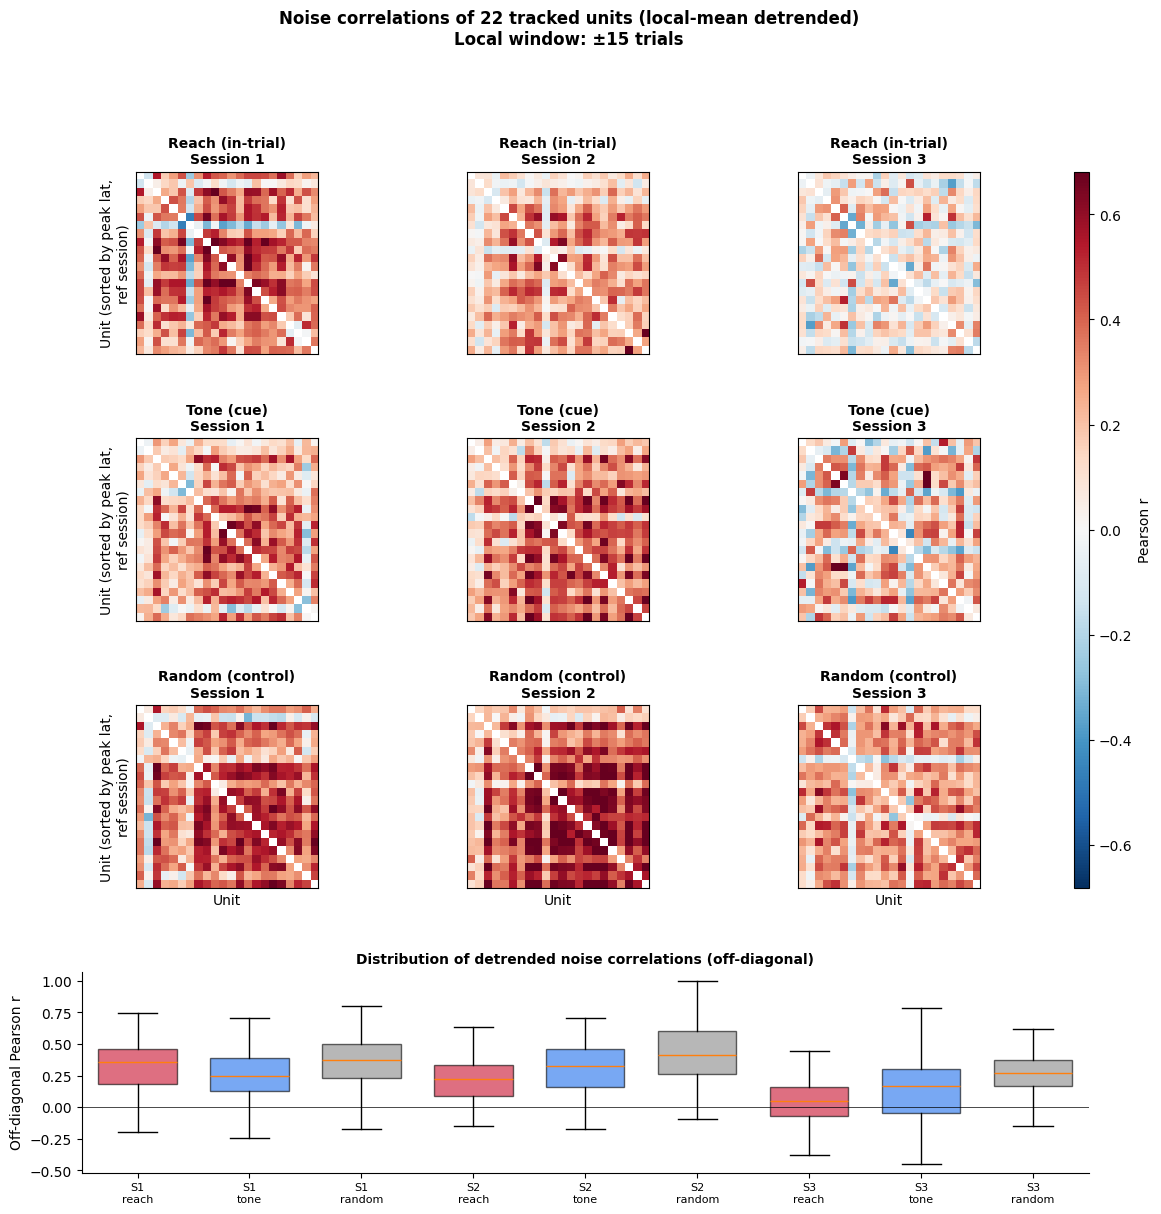

Saved → GRANT_noise_correlations_detrended.png/.pdf/.svg

===== Median off-diagonal r (detrended) =====
Event          Session 1     Session 2     Session 3
reach             +0.354        +0.223        +0.049
tone              +0.246        +0.323        +0.171
random            +0.376        +0.409        +0.269

===== DONE =====



In [4]:
# ============================================================
# NOISE CORRELATIONS WITH LOCAL-MEAN DETRENDING
# ============================================================
# Same setup as the previous noise correlation cell, but residuals
# are computed by subtracting a sliding local mean rather than the
# global mean. This removes slow brain-state drift on the
# minutes-scale that contaminates noise correlation estimates.
#
# LOCAL_WINDOW_TRIALS controls the smoothing scale: smaller = more
# aggressive detrending (removes faster fluctuations); larger =
# closer to global mean. 20-40 is a reasonable starting range.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

print("\n===== NOISE CORRELATIONS (detrended) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_BASE = r"G:\Kevin\unit_matching"

WINDOW_S = (0.0, 2.0)
TONE_PIN = 4
N_RANDOM_EVENTS = 100
RANDOM_SEED = 42
LOCAL_WINDOW_TRIALS = 30   # # of nearest-in-time trials for local-mean baseline
# ------------------------------------------------------------

output_base = Path(OUTPUT_BASE)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
focus_names = [Path(sf).name for sf in SESSION_ANALYSIS_FOLDERS]
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# LOAD TRACKED UNITS + EVENTS + SPIKES (same as before)
# ------------------------------------------------------------
ch = np.load(output_base / "tracked_units_chains.npz", allow_pickle=True)
all_session_names = list(ch["session_names"])
units_by_session_full = ch["units_by_session"]
focus_cols = [all_session_names.index(fn) for fn in focus_names]
units_focus_all = units_by_session_full[:, focus_cols]
keep_mask = (units_focus_all >= 0).all(axis=1)
units_focus = units_focus_all[keep_mask]
n_units = len(units_focus)
print(f"Tracked units: {n_units}")

session_events = []
session_durations = []
spikes_per_session = []
for si, sf in enumerate(SESSION_ANALYSIS_FOLDERS):
    af = Path(sf)
    with open(af / "metadata" / "session.json") as f:
        sess = json.load(f)
    dur = float(sess["recording_duration_s"])
    session_durations.append(dur)
    bouts = np.load(af / "peak_detection" / "bouts.npz")
    reach = np.sort(bouts["onset_t"][bouts["trial_id"] >= 0])
    tone = np.sort(np.load(af / "ttls" / f"TTL_Pin_{TONE_PIN}.npy"))
    t_min = abs(WINDOW_S[0]) + 1.0; t_max = dur - WINDOW_S[1] - 1.0
    random_events = np.sort(rng.uniform(t_min, t_max, size=N_RANDOM_EVENTS))
    session_events.append({"reach": reach, "tone": tone, "random": random_events})

    spikes_dir = af / "spikes"
    sd = {int(uid): np.sort(np.load(spikes_dir / f"unit_{int(uid)}.npy"))
          for uid in units_focus[:, si]}
    spikes_per_session.append(sd)

# ------------------------------------------------------------
# SPIKE COUNTS PER TRIAL
# ------------------------------------------------------------
def spike_counts_per_trial(spike_times, events, win):
    counts = np.zeros(len(events))
    for i, t in enumerate(events):
        lo = t + win[0]; hi = t + win[1]
        counts[i] = np.searchsorted(spike_times, hi) - np.searchsorted(spike_times, lo)
    return counts

event_types = ["reach", "tone", "random"]
event_labels = {"reach": "Reach (in-trial)",
                "tone": "Tone (cue)",
                "random": "Random (control)"}

counts = {evt: [] for evt in event_types}
for si in range(n_sessions):
    for evt in event_types:
        events = session_events[si][evt]
        mat = np.zeros((len(events), n_units))
        for ui in range(n_units):
            uid = int(units_focus[ui, si])
            mat[:, ui] = spike_counts_per_trial(spikes_per_session[si][uid],
                                                events, WINDOW_S)
        counts[evt].append(mat)

# ------------------------------------------------------------
# LOCAL-MEAN DETRENDED NOISE CORRELATIONS
# ------------------------------------------------------------
def local_detrend(c, win_trials):
    """For each unit, subtract a local moving average over `win_trials` trials.
       c: (n_events, n_units), events assumed sorted by time.
       Returns: residuals of same shape."""
    n_events, n_u = c.shape
    if n_events <= win_trials:
        return c - c.mean(axis=0, keepdims=True)
    half = win_trials // 2
    resid = np.zeros_like(c, dtype=float)
    for i in range(n_events):
        lo = max(0, i - half); hi = min(n_events, i + half + 1)
        local_mean = c[lo:hi].mean(axis=0)
        resid[i] = c[i] - local_mean
    return resid

noise_corr = {evt: [] for evt in event_types}
for si in range(n_sessions):
    for evt in event_types:
        c = counts[evt][si]
        if c.shape[0] < 2:
            noise_corr[evt].append(np.full((n_units, n_units), np.nan))
            continue
        resid = local_detrend(c, LOCAL_WINDOW_TRIALS)
        stds = resid.std(axis=0)
        valid = stds > 0
        cm = np.full((n_units, n_units), np.nan)
        if valid.sum() >= 2:
            cm_valid = np.corrcoef(resid[:, valid], rowvar=False)
            idx_valid = np.where(valid)[0]
            for i_v, ii in enumerate(idx_valid):
                for j_v, jj in enumerate(idx_valid):
                    cm[ii, jj] = cm_valid[i_v, j_v]
        noise_corr[evt].append(cm)

# ------------------------------------------------------------
# UNIT ORDER (same as previous cells: peak latency on session 0)
# ------------------------------------------------------------
fps = []
for sf in SESSION_ANALYSIS_FOLDERS:
    fp = dict(np.load(Path(sf) / "fingerprints" / "unit_fingerprints.npz",
                      allow_pickle=True))
    fps.append(fp)
def uidx_in_fp(fp, uid):
    return int(np.where(fp["unit_ids"] == uid)[0][0])
ref_latencies = np.array([
    float(fps[0]["reach_peak_lat"][
        uidx_in_fp(fps[0], int(units_focus[ui, 0]))
    ]) for ui in range(n_units)
])
order = np.argsort(ref_latencies)

# ------------------------------------------------------------
# PLOTTING (same layout as previous noise corr figure)
# ------------------------------------------------------------
n_evt = len(event_types)
fig = plt.figure(figsize=(4.0 * n_sessions + 1.0, 3.5 * n_evt + 2.5))
gs = GridSpec(n_evt + 1, n_sessions + 1,
              height_ratios=[1] * n_evt + [1.1],
              width_ratios=[1] * n_sessions + [0.05],
              hspace=0.45, wspace=0.18)

all_off = []
for evt in event_types:
    for si in range(n_sessions):
        m = noise_corr[evt][si]
        mask = ~np.eye(n_units, dtype=bool)
        v = m[mask]; all_off.append(v[np.isfinite(v)])
all_off = np.concatenate(all_off)
vmax = max(np.percentile(np.abs(all_off), 98), 0.2)

for ei, evt in enumerate(event_types):
    for si in range(n_sessions):
        ax = fig.add_subplot(gs[ei, si])
        cm = noise_corr[evt][si][np.ix_(order, order)]
        cm_display = cm.copy()
        np.fill_diagonal(cm_display, np.nan)
        im = ax.imshow(cm_display, cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, interpolation="nearest")
        ax.set_title(f"{event_labels[evt]}\n{SESSION_LABELS[si]}",
                     fontsize=10, fontweight="bold")
        if si == 0:
            ax.set_ylabel("Unit (sorted by peak lat,\nref session)")
        if ei == n_evt - 1:
            ax.set_xlabel("Unit")
        ax.set_xticks([]); ax.set_yticks([])

cax = fig.add_subplot(gs[:n_evt, -1])
plt.colorbar(im, cax=cax, label="Pearson r")

ax_sum = fig.add_subplot(gs[n_evt, :])
evt_colors = {"reach": "#C8102E", "tone": "#1f6feb", "random": "#888888"}
positions = np.arange(n_sessions * len(event_types))
box_data = []; labels_x = []; color_seq = []
for si in range(n_sessions):
    for evt in event_types:
        m = noise_corr[evt][si]
        mask = ~np.eye(n_units, dtype=bool)
        v = m[mask]; v = v[np.isfinite(v)]
        box_data.append(v)
        labels_x.append(f"{SESSION_LABELS[si].replace('Session ', 'S')}\n{evt}")
        color_seq.append(evt_colors[evt])
bp = ax_sum.boxplot(box_data, positions=positions, widths=0.7,
                    patch_artist=True, showfliers=False)
for patch, col in zip(bp["boxes"], color_seq):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax_sum.axhline(0, color="black", lw=0.5)
ax_sum.set_xticks(positions)
ax_sum.set_xticklabels(labels_x, fontsize=8)
ax_sum.set_ylabel("Off-diagonal Pearson r")
ax_sum.set_title("Distribution of detrended noise correlations (off-diagonal)",
                 fontsize=10, fontweight="bold")
ax_sum.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Noise correlations of {n_units} tracked units (local-mean detrended)\n"
             f"Local window: ±{LOCAL_WINDOW_TRIALS // 2} trials",
             fontsize=12, fontweight="bold", y=1.005)

out_base = output_base / "GRANT_noise_correlations_detrended"
for ext in ("png", "pdf", "svg"):
    plt.savefig(f"{out_base}.{ext}",
                dpi=300 if ext == "png" else None,
                bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved → {out_base.name}.png/.pdf/.svg")

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
print(f"\n===== Median off-diagonal r (detrended) =====")
print(f"{'Event':<10}" + "".join(f"{lab:>14}" for lab in SESSION_LABELS))
for evt in event_types:
    row = f"{evt:<10}"
    for si in range(n_sessions):
        m = noise_corr[evt][si]
        mask = ~np.eye(n_units, dtype=bool)
        v = m[mask]; v = v[np.isfinite(v)]
        row += f"{np.median(v):>+14.3f}"
    print(row)

print("\n===== DONE =====\n")